In [1]:
import pandas as pd

In [2]:
pv_df = pd.read_csv("data/pv_kW.csv")
pv_df.index = pd.to_datetime(pv_df.utc_timestamp, utc=True)
pv_df = pv_df.drop("utc_timestamp", axis='columns')

In [3]:
from smart_grid_lab.ui_dash.plot_utils import build_figure

In [8]:
# build_figure(pv_df, ["pv"], [])

In [9]:
train_start = pd.Timestamp("2016-03-15T00:00:00Z")
train_end = train_start + pd.Timedelta(450, "D")

In [10]:
test_start = train_end + pd.Timedelta(150, "D")
test_end = test_start + pd.Timedelta(21, "D")

In [11]:
forecast_start = test_end - pd.Timedelta(7, "D")

In [12]:
pv_train = pv_df[train_start : train_end]

In [13]:
pv_test = pv_df[test_start : test_end]

In [14]:
from smart_grid_lab.infrastructure.forecasting import OpenSTEFGBLinearPVForecastAdapter

In [15]:
pv_adapter = OpenSTEFGBLinearPVForecastAdapter()

In [ ]:
pv_adapter.openstef_adapter.train(pv_train)

/home/eduard/anaconda3/envs/energy-ml-13/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [13:42:46] WARNING: /workspace/src/learner.cc:825: `booster=gblinear` is deprecated and support will be removed in a future release.
  self.starting_round = model.num_boosted_rounds()
/home/eduard/anaconda3/envs/energy-ml-13/lib/python3.13/site-packages/xgboost/core.py:569: UserWarning: [13:42:47] WARNING: /workspace/src/learner.cc:825: `booster=gblinear` is deprecated and support will be removed in a future release.
  return func(**kwargs)


In [ ]:
forecast_dataset = pv_adapter.openstef_adapter.test(pv_test, at=forecast_start)

In [18]:
import matplotlib.pyplot as plt

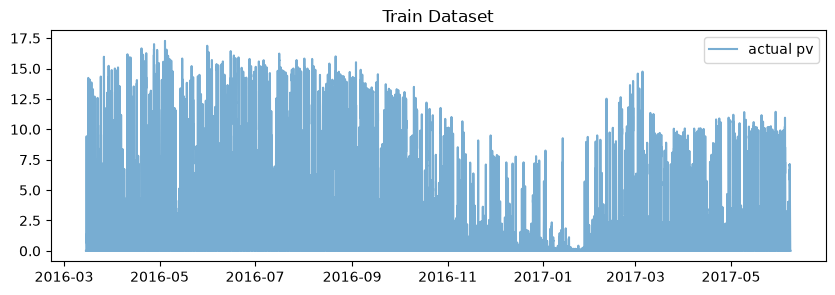

In [19]:
plt.figure(figsize=(10,3))

# to inspect train dataset
plt.plot(pv_train.index, 
         pv_train["pv"], 
         alpha=0.6, 
         label="actual pv")

plt.legend()
plt.title("Train Dataset")
plt.show()

In [20]:
pv_train

,pv
utc_timestamp,
2016-03-15 00:00:00+00:00,0.0
2016-03-15 00:15:00+00:00,0.0
2016-03-15 00:30:00+00:00,0.0
2016-03-15 00:45:00+00:00,0.0
2016-03-15 01:00:00+00:00,0.0
...,...
2017-06-07 23:00:00+00:00,0.0
2017-06-07 23:15:00+00:00,0.0
2017-06-07 23:30:00+00:00,0.0


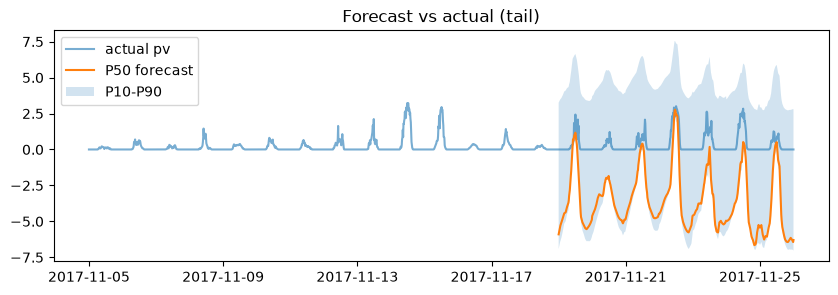

In [21]:
plt.figure(figsize=(10,3))

# actual
plt.plot(pv_test.index, 
         pv_test["pv"], 
         alpha=0.6, 
         label="actual pv")

# forecast
plt.plot(forecast_dataset.data.index, forecast_dataset.data["quantile_P50"], label="P50 forecast")

# 'confidence' interval
plt.fill_between(forecast_dataset.data.index, 
                 forecast_dataset.data["quantile_P10"], 
                 forecast_dataset.data["quantile_P90"], 
                 alpha=0.2, 
                 label="P10-P90")

plt.legend()
plt.title("Forecast vs actual (tail)")
plt.show()

# Test Inference

In [22]:
history=pv_test[test_start : forecast_start-pv_adapter.openstef_adapter.sample_interval]

In [23]:
inference_forecast = pv_adapter.forecast_pv_kW(history=history, 
                          at=forecast_start,
                          horizon=pd.Timedelta(7, "D"))

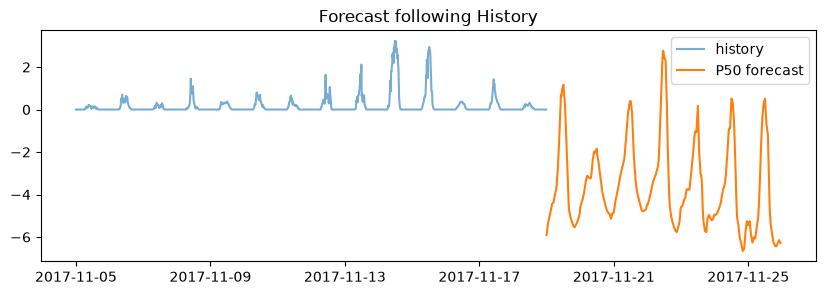

In [24]:
plt.figure(figsize=(10,3))

# history
plt.plot(history.index, 
         history["pv"], 
         alpha=0.6, 
         label="history")

# forecast
plt.plot(inference_forecast.index, inference_forecast, label="P50 forecast")

plt.legend()
plt.title("Forecast following History")
plt.show()